# V1 Experiment Evaluation

Auto-discovering evaluation notebook for the v1 experimental framework.
Analyzes results across 5 models × 4 context conditions (c0-c3).

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-discover model folders
V1_DIR = Path(".").resolve()
MODEL_DIRS = [d for d in V1_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"Discovered model folders: {[d.name for d in MODEL_DIRS]}")

Discovered model folders: ['mistral_medium', 'gpt_4_1_openai']


In [2]:
# Style configuration for thesis-quality visualizations
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 14, "axes.labelsize": 12})
sns.set_theme(style="whitegrid", palette="colorblind")
CONTEXT_COLORS = {"c0": "#1f77b4", "c1": "#ff7f0e", "c2": "#2ca02c", "c3": "#d62728"}

In [3]:
def load_results(model_dir: Path) -> list[dict]:
    """Load all JSON result files from a model directory."""
    results = []
    for json_file in model_dir.glob("*.json"):
        with open(json_file) as f:
            data = json.load(f)
            data["_file"] = json_file.name
            data["_model_dir"] = model_dir.name
            results.append(data)
    return results

# Load all results
all_results = []
for model_dir in MODEL_DIRS:
    all_results.extend(load_results(model_dir))

print(f"Loaded {len(all_results)} result files")

Loaded 5 result files


In [4]:
def extract_metrics(result: dict) -> list[dict]:
    """Extract per-dataset metrics from a result file."""
    rows = []
    config = result.get("config", {})
    model_dir = result.get("_model_dir", "unknown")
    experiment = config.get("experiment", {}).get("experiment_name", "unknown")
    model = config.get("llm", {}).get("model", "unknown")
    context_sources = config.get("context", {}).get("sources", [])
    
    # JSON uses "datasets" key, not "results"
    for dataset, metrics in result.get("datasets", {}).items():
        reports = metrics.get("reports", {})
        for manipulation in ["original", "content_only", "shuffle"]:
            report = reports.get(manipulation, {})
            macro_f1 = report.get("macro avg", {}).get("f1-score", np.nan)
            accuracy = report.get("accuracy", np.nan)
            
            rows.append({
                "model_dir": model_dir,
                "model": model,
                "context": experiment,
                "context_sources": ", ".join(context_sources),
                "dataset": dataset,
                "manipulation": manipulation,
                "macro_f1": macro_f1,
                "accuracy": accuracy,
            })
    return rows

# Build flat DataFrame
rows = []
for result in all_results:
    rows.extend(extract_metrics(result))

df = pd.DataFrame(rows)
print(f"Built DataFrame with {len(df)} rows")
df.head(10)

Built DataFrame with 96 rows


,model_dir,model,context,context_sources,dataset,manipulation,macro_f1,accuracy
0,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ABSTRCT,original,0.833148,0.833333
1,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ABSTRCT,content_only,0.691429,0.700000
2,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ABSTRCT,shuffle,0.576380,0.633333
3,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ARGUMINSCI,original,0.670330,0.700000
4,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ARGUMINSCI,content_only,0.523810,0.600000
5,mistral_medium,mistral-medium-latest,c2,"definition, guideline",ARGUMINSCI,shuffle,0.333333,0.500000
6,mistral_medium,mistral-medium-latest,c2,"definition, guideline",PE,original,0.583333,0.600000
7,mistral_medium,mistral-medium-latest,c2,"definition, guideline",PE,content_only,0.566185,0.566667
8,mistral_medium,mistral-medium-latest,c2,"definition, guideline",PE,shuffle,0.422336,0.500000
9,mistral_medium,mistral-medium-latest,c2,"definition, guideline",USELEC,original,0.796380,0.800000


## C1 Fallback for C2/C3 Aggregate Calculations

**Important:** c2 and c3 only run on 4 datasets with annotation guidelines:
- ABSTRCT, ARGUMINSCI, PE, USELEC

The remaining 6 datasets (ACQUA, AEC, AFS, FINARG, IAM, SCIARK) don't have guidelines, so:
- **c2/c3 cannot provide additional context beyond c1 for these datasets**
- **For aggregate metrics, we use c1 results as the effective c2/c3 performance**

This ensures fair 10-dataset comparisons across all context conditions.

In [5]:
# =============================================================================
# C1 FALLBACK LOGIC FOR C2/C3
# =============================================================================
# Datasets WITH guidelines (run in c2/c3):
GUIDELINE_DATASETS = {"ABSTRCT", "ARGUMINSCI", "PE", "USELEC"}

# Datasets WITHOUT guidelines (use c1 results for c2/c3):
NO_GUIDELINE_DATASETS = {"ACQUA", "AEC", "AFS", "FINARG", "IAM", "SCIARK"}

def fill_c2_c3_with_c1_fallback(df: pd.DataFrame) -> pd.DataFrame:
    """
    For c2/c3 aggregate calculations, fill missing datasets with c1 results.
    Only adds fallback for models that actually have c2/c3 results.
    """
    if df.empty:
        return df

    df_filled = df.copy()

    for target_context in ["c2", "c3"]:
        # Get models that have actual results for this context (on guideline datasets)
        models_with_ctx = df[
            (df["context"] == target_context) &
            (df["dataset"].isin(GUIDELINE_DATASETS))
        ]["model_dir"].unique()

        if len(models_with_ctx) == 0:
            continue

        # Get c1 data for non-guideline datasets, only for those models
        fallback = df[
            (df["context"] == "c1") &
            (df["model_dir"].isin(models_with_ctx)) &
            (df["dataset"].isin(NO_GUIDELINE_DATASETS))
        ].copy()

        if not fallback.empty:
            fallback["context"] = target_context
            fallback["context_sources"] = "[c1 fallback]"
            df_filled = pd.concat([df_filled, fallback], ignore_index=True)
            print(f"Added c1 fallback for {target_context}: {len(fallback)} rows for {list(models_with_ctx)}")

    return df_filled

# Create filled DataFrame for aggregate calculations
df_filled = fill_c2_c3_with_c1_fallback(df)

# Show what was added
if not df_filled.empty:
    actual_contexts = df["context"].unique()
    filled_contexts = df_filled["context"].unique()
    print(f"\nOriginal df: {len(df)} rows, contexts: {sorted(actual_contexts)}")
    print(f"Filled df:   {len(df_filled)} rows, contexts: {sorted(filled_contexts)}")
    
    # Show c2/c3 details only if they exist
    for ctx in ["c2", "c3"]:
        if ctx in filled_contexts:
            ctx_datasets = df_filled[df_filled["context"] == ctx]["dataset"].unique()
            print(f"\n{ctx} datasets: {sorted(ctx_datasets)}")
else:
    print("No data loaded yet")

Added c1 fallback for c2: 36 rows for ['mistral_medium', 'gpt_4_1_openai']
Added c1 fallback for c3: 18 rows for ['mistral_medium']

Original df: 96 rows, contexts: ['c1', 'c2', 'c3']
Filled df:   150 rows, contexts: ['c1', 'c2', 'c3']

c2 datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

c3 datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']


## Performance Overview

In [6]:
# =============================================================================
# USING df_filled: c2/c3 include c1 fallback for non-guideline datasets
# =============================================================================
original_df_filled = df_filled[df_filled["manipulation"] == "original"]

pivot_f1 = original_df_filled.pivot_table(
    values="macro_f1",
    index="model_dir",
    columns="context",
    aggfunc="mean"
)

# Reorder columns if they exist
col_order = [c for c in ["c0", "c1", "c2", "c3"] if c in pivot_f1.columns]
if col_order:
    pivot_f1 = pivot_f1[col_order]

print("Mean Macro-F1 (Original Text) by Model × Context")
print("NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets")
pivot_f1.round(3)

Mean Macro-F1 (Original Text) by Model × Context
NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets


context,c1,c2,c3
model_dir,,,
gpt_4_1_openai,0.702,0.730,NaN
mistral_medium,0.695,0.709,0.693


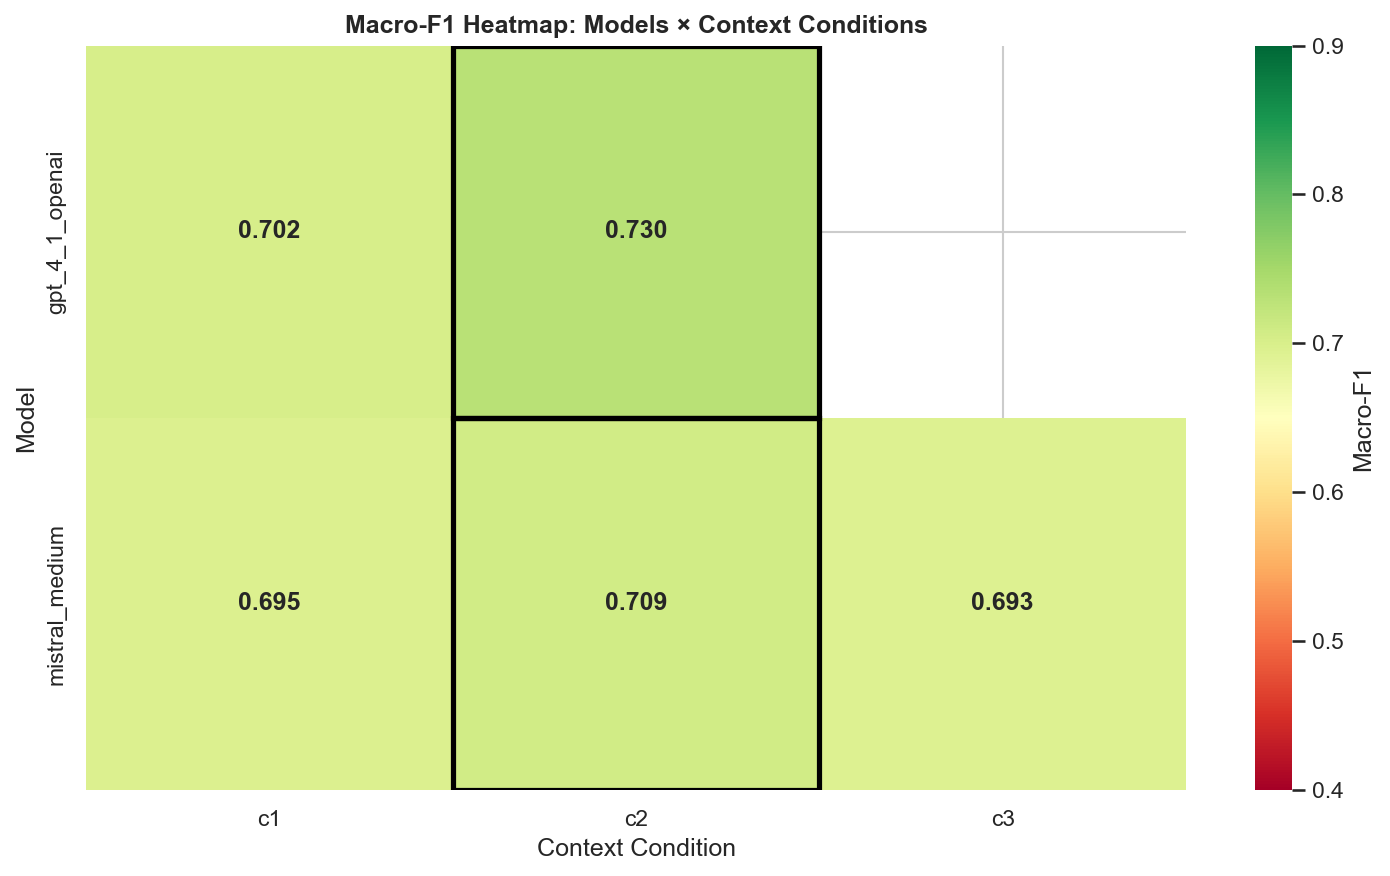

In [7]:
# F1 Heatmap with enhanced styling
from matplotlib.patches import Rectangle

if not pivot_f1.empty:
    # Sort models by mean F1 descending
    pivot_f1_sorted = pivot_f1.loc[pivot_f1.mean(axis=1).sort_values(ascending=False).index]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_f1_sorted, annot=True, fmt=".3f", cmap="RdYlGn", 
                vmin=0.4, vmax=0.9, ax=ax,
                annot_kws={"size": 12, "weight": "bold"},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(pivot_f1_sorted.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, 
                                    edgecolor="black", linewidth=2.5))
    
    ax.set_title("Macro-F1 Heatmap: Models × Context Conditions", fontweight="bold")
    ax.set_xlabel("Context Condition")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap")

## Delta Analysis (Shortcut Learning)

In [8]:
# Calculate deltas: Content-Only and Shuffle vs Original
# Using df_filled for consistent 10-dataset comparison across all contexts
def calculate_deltas(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate delta_content_only and delta_shuffle for each model/context/dataset."""
    pivot = df.pivot_table(
        values="macro_f1",
        index=["model_dir", "context", "dataset"],
        columns="manipulation",
        aggfunc="mean"
    ).reset_index()
    
    if "original" in pivot.columns:
        if "content_only" in pivot.columns:
            pivot["delta_content_only"] = pivot["content_only"] - pivot["original"]
        if "shuffle" in pivot.columns:
            pivot["delta_shuffle"] = pivot["shuffle"] - pivot["original"]
    
    return pivot

deltas_df = calculate_deltas(df_filled)  # Using df_filled!
deltas_df.head()

manipulation,model_dir,context,dataset,content_only,original,shuffle,delta_content_only,delta_shuffle
0,gpt_4_1_openai,c1,ABSTRCT,0.513889,0.541716,0.499444,-0.027827,-0.042272
1,gpt_4_1_openai,c1,ACQUA,0.632925,0.760000,0.541716,-0.127075,-0.218284
2,gpt_4_1_openai,c1,AEC,0.523810,0.592760,0.333333,-0.068951,-0.259427
3,gpt_4_1_openai,c1,AFS,0.550000,0.696970,0.403409,-0.146970,-0.293561
4,gpt_4_1_openai,c1,ARGUMINSCI,0.592760,0.732143,0.333333,-0.139383,-0.398810


In [9]:
# Mean deltas by model and context
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    delta_summary = deltas_df.groupby(["model_dir", "context"])[["delta_content_only", "delta_shuffle"]].mean()
    print("Mean Deltas (negative = performance drop under manipulation)")
    display(delta_summary.round(3))
else:
    print("Not enough manipulations to calculate deltas")

Mean Deltas (negative = performance drop under manipulation)


manipulation            delta_content_only  delta_shuffle
model_dir      context                                   
gpt_4_1_openai c1                   -0.111         -0.267
               c2                   -0.117         -0.261
mistral_medium c1                   -0.120         -0.264
               c2                   -0.105         -0.246
               c3                   -0.090         -0.194

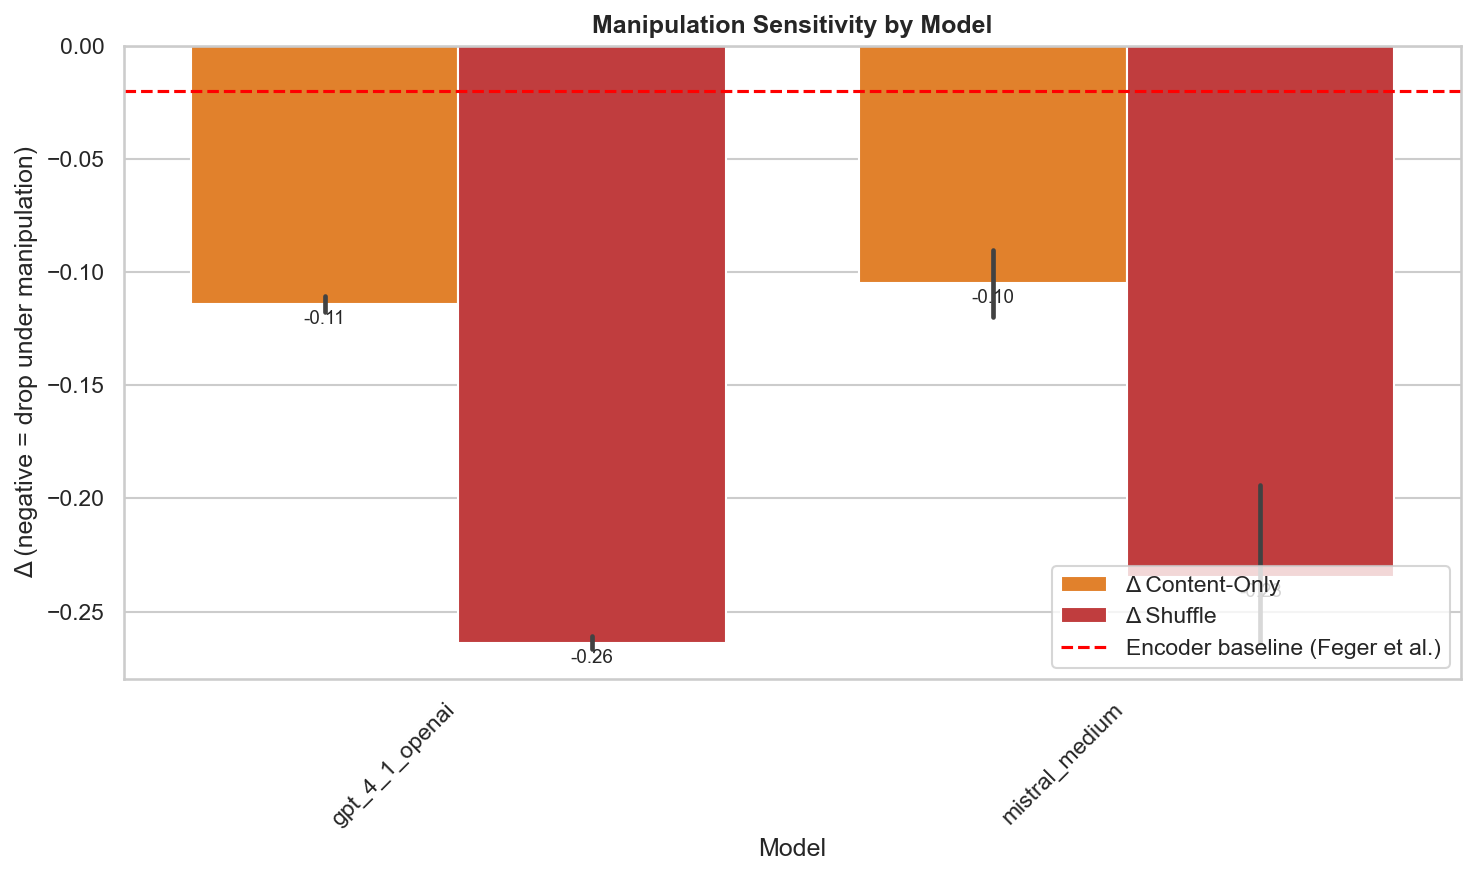

In [10]:
# =============================================================================
# DELTA BAR CHART: Manipulation Sensitivity by Model
# =============================================================================
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    # Prepare delta summary for plotting
    delta_plot = delta_summary.reset_index()
    delta_melted = delta_plot.melt(
        id_vars=["model_dir", "context"],
        value_vars=["delta_content_only", "delta_shuffle"],
        var_name="manipulation",
        value_name="delta"
    )
    # Rename for cleaner legend
    delta_melted["manipulation"] = delta_melted["manipulation"].map({
        "delta_content_only": "Δ Content-Only",
        "delta_shuffle": "Δ Shuffle"
    })
    
    # Sort models by mean F1 descending
    model_order = pivot_f1.mean(axis=1).sort_values(ascending=False).index.tolist()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=delta_melted, x="model_dir", y="delta", hue="manipulation", 
                ax=ax, order=model_order, palette=["#ff7f0e", "#d62728"])
    
    # Reference lines
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(-0.02, color="red", linestyle="--", linewidth=1.5, 
               label="Encoder baseline (Feger et al.)")
    
    # Value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    ax.set_ylabel("Δ (negative = drop under manipulation)")
    ax.set_xlabel("Model")
    ax.set_title("Manipulation Sensitivity by Model", fontweight="bold")
    ax.legend(loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for delta bar chart")

## Per-Dataset Performance

In [11]:
# Per-dataset F1 for c1 (definition context)
c1_original = df[(df["context"] == "c1") & (df["manipulation"] == "original")]

if not c1_original.empty:
    per_dataset = c1_original.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="model_dir",
        aggfunc="mean"
    )
    print("c1 (Definition) Macro-F1 by Dataset × Model")
    display(per_dataset.round(3))
else:
    print("No c1 results available")

c1 (Definition) Macro-F1 by Dataset × Model


model_dir,gpt_4_1_openai,mistral_medium
dataset,,
ABSTRCT,0.542,0.766
ACQUA,0.760,0.832
AEC,0.593,0.495
AFS,0.697,0.667
ARGUMINSCI,0.732,0.753
FINARG,0.722,0.576
IAM,0.833,0.799
PE,0.653,0.598
SCIARK,0.800,0.833


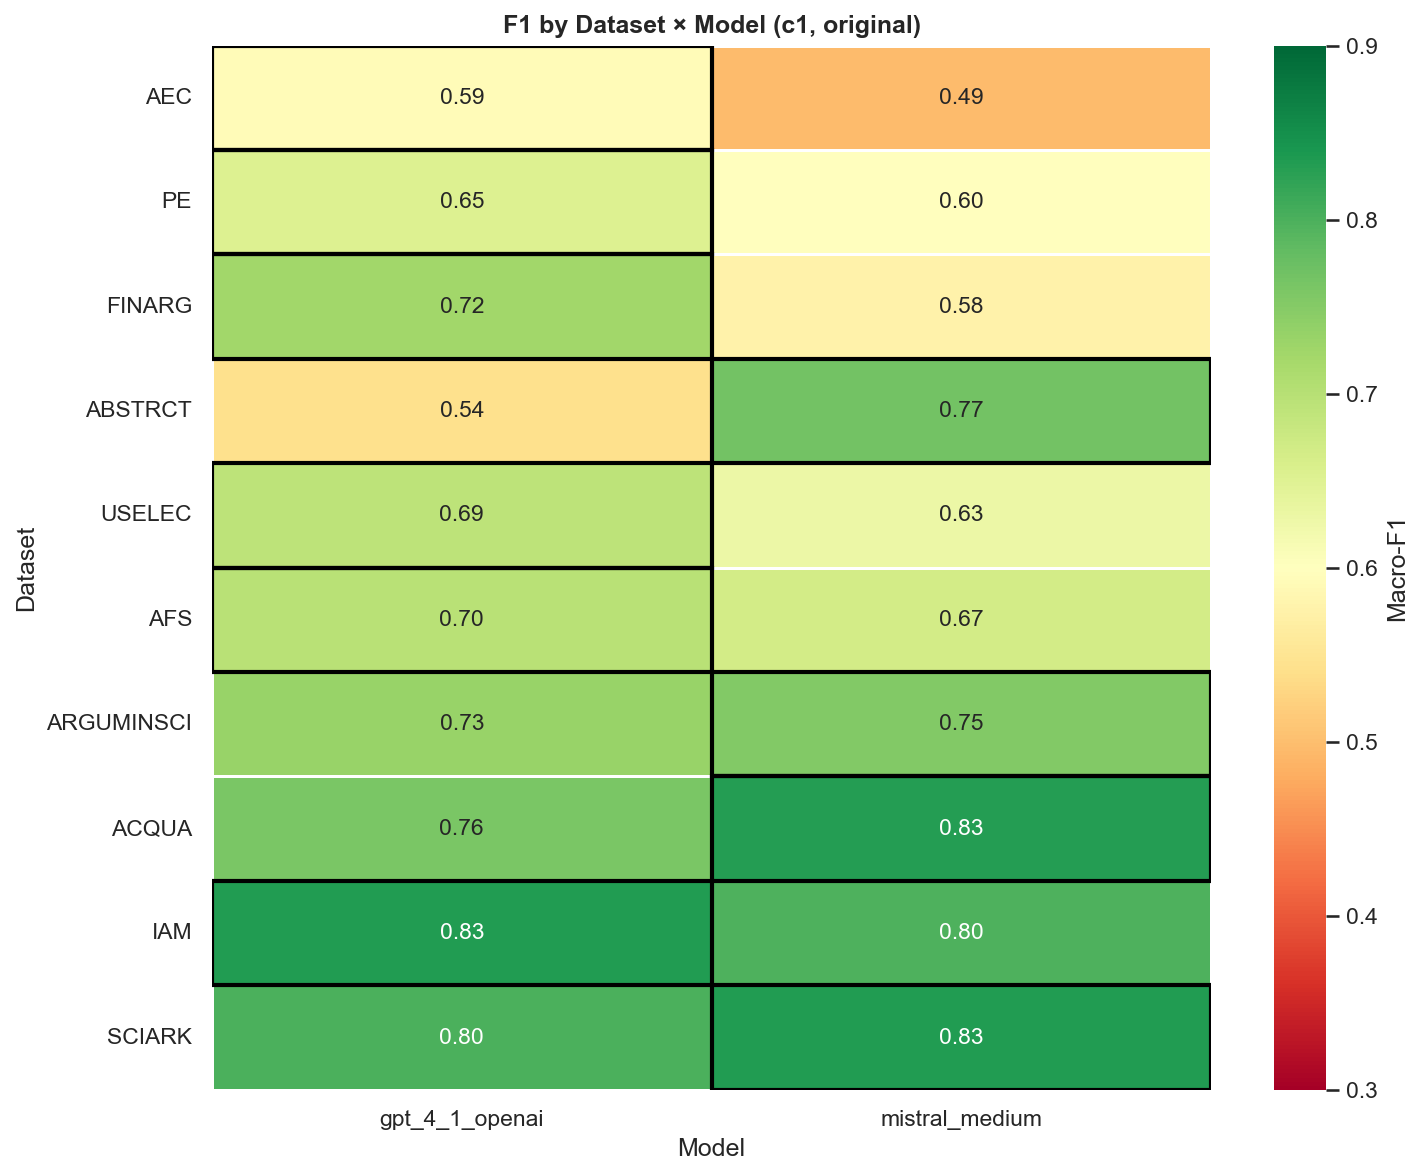

In [12]:
# =============================================================================
# PER-DATASET HEATMAP: F1 by Dataset × Model
# =============================================================================
if not c1_original.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sort datasets by mean F1, models by mean F1
    sorted_pivot = per_dataset.loc[per_dataset.mean(axis=1).sort_values().index]
    sorted_pivot = sorted_pivot[sorted_pivot.mean().sort_values(ascending=False).index]
    
    sns.heatmap(sorted_pivot, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0.3, vmax=0.9, linewidths=0.5, ax=ax,
                annot_kws={"size": 11},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(sorted_pivot.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor="black", linewidth=2))
    
    ax.set_title("F1 by Dataset × Model (c1, original)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Dataset")
    plt.tight_layout()
    plt.show()
else:
    print("No c1 results available for heatmap")

## Context Ladder Visualization

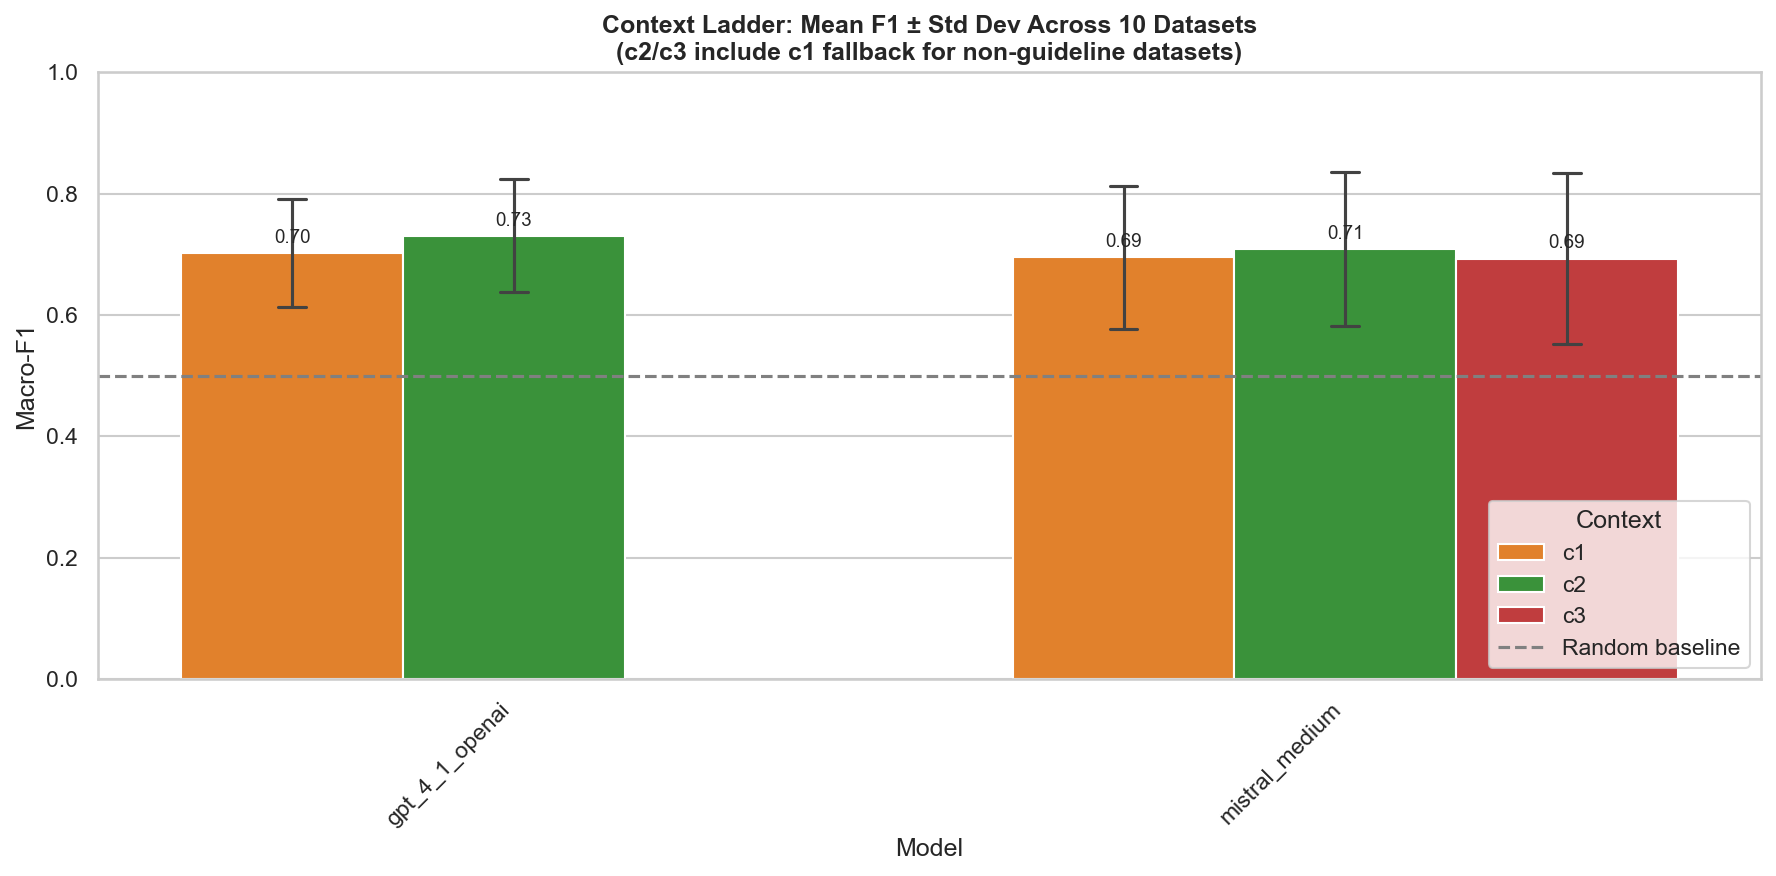

In [13]:
# Bar chart with error bars: F1 mean ± std across 10 datasets
# Using df_filled for fair 10-dataset comparison (c2/c3 include c1 fallback)
if not original_df_filled.empty:
    # Sort contexts
    context_order_list = ["c0", "c1", "c2", "c3"]
    plot_df = original_df_filled.copy()
    plot_df["context"] = pd.Categorical(
        plot_df["context"], 
        categories=[c for c in context_order_list if c in plot_df["context"].unique()],
        ordered=True
    )
    
    # Sort models by mean F1 descending
    model_order = plot_df.groupby("model_dir")["macro_f1"].mean().sort_values(ascending=False).index.tolist()
    
    # Build color palette from CONTEXT_COLORS
    available_contexts = [c for c in context_order_list if c in plot_df["context"].unique()]
    palette = [CONTEXT_COLORS.get(c, "#333333") for c in available_contexts]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x="model_dir", y="macro_f1", hue="context",
                order=model_order, palette=palette, ax=ax,
                errorbar="sd", capsize=0.1, err_kws={"linewidth": 1.5})
    
    # Add value labels on bars (mean values)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    # Random baseline reference line
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="Random baseline")
    
    ax.set_title("Context Ladder: Mean F1 ± Std Dev Across 10 Datasets\n(c2/c3 include c1 fallback for non-guideline datasets)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 1)
    ax.legend(title="Context", loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for context ladder")

## Summary Statistics

In [14]:
# Summary: Mean F1, Std by model/context
# Using df_filled for consistent 10-dataset comparison
if not original_df_filled.empty:
    summary = original_df_filled.groupby(["model_dir", "context"])["macro_f1"].agg(["mean", "std", "count"])
    summary.columns = ["Mean F1", "Std", "N Datasets"]
    print("Summary Statistics (Original Text)")
    print("NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets")
    display(summary.round(3))
else:
    print("No data available for summary")

Summary Statistics (Original Text)
NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets


Mean F1    Std  N Datasets
model_dir      context                            
gpt_4_1_openai c1         0.702  0.089          10
               c2         0.730  0.093          10
mistral_medium c1         0.695  0.118          10
               c2         0.709  0.127          10
               c3         0.693  0.140          10

In [15]:
# Export results tables
if len(df) > 0:
    # Raw results (actual experiment outputs only)
    raw_path = V1_DIR / "results_raw.csv"
    df.to_csv(raw_path, index=False)
    print(f"Exported raw results to {raw_path}")
    
    # Filled results (c2/c3 include c1 fallback for non-guideline datasets)
    filled_path = V1_DIR / "results_filled.csv"
    df_filled.to_csv(filled_path, index=False)
    print(f"Exported filled results to {filled_path}")
    print("  -> Use results_filled.csv for aggregate comparisons across context conditions")
else:
    print("No results to export yet")

Exported raw results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v2/results_raw.csv
Exported filled results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v2/results_filled.csv
  -> Use results_filled.csv for aggregate comparisons across context conditions


## Comprehensive Performance Tables

In [16]:
# =============================================================================
# TABLE 1: F1 Scores by Model x Context x Dataset
# =============================================================================

all_datasets = sorted(df["dataset"].unique())
original_only = df[df["manipulation"] == "original"]

# Pivot: rows = (model_dir, context), columns = dataset
f1_pivot = original_only.pivot_table(
    values="macro_f1",
    index=["model_dir", "context"],
    columns="dataset",
    aggfunc="mean"
)
f1_pivot["Avg"] = f1_pivot.mean(axis=1)

# Sort by context order
context_order = {"c0": 0, "c1": 1, "c2": 2, "c3": 3}
f1_pivot = f1_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 Scores (Original Text) ===\n")
print(f1_pivot.round(3).to_string())

# Enhanced styling: gradient first, then max highlight with border only (no background override)
styled_f1 = f1_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_f1)

=== F1 Scores (Original Text) ===

dataset                 ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  SCIARK  USELEC    Avg
model_dir      context                                                                                       
gpt_4_1_openai c1         0.542  0.760  0.593  0.697       0.732   0.722  0.833  0.653   0.800   0.691  0.702
               c2         0.866    NaN    NaN    NaN       0.753     NaN    NaN  0.583     NaN   0.697  0.725
mistral_medium c1         0.766  0.832  0.495  0.667       0.753   0.576  0.799  0.598   0.833   0.630  0.695
               c2         0.833    NaN    NaN    NaN       0.670     NaN    NaN  0.583     NaN   0.796  0.721
               c3         0.833    NaN    NaN    NaN       0.670     NaN    NaN  0.471     NaN   0.753  0.682


In [17]:
# =============================================================================
# TABLE 2: Manipulation Sensitivity (Delta values)
# =============================================================================
# More negative delta = larger performance drop = relies on linguistic structure

delta_cols = ["delta_content_only", "delta_shuffle"]
if all(c in deltas_df.columns for c in delta_cols):
    # Aggregate deltas by model/context
    delta_agg = deltas_df.groupby(["model_dir", "context"]).agg({
        "delta_content_only": "mean",
        "delta_shuffle": "mean",
        "dataset": "count"
    }).rename(columns={"dataset": "n_datasets"})
    
    # Add mean absolute delta
    delta_agg["mean_abs_delta"] = (
        delta_agg["delta_content_only"].abs() + delta_agg["delta_shuffle"].abs()
    ) / 2
    
    # Sort by context order
    delta_agg = delta_agg.sort_index(
        key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
    )
    
    print("=== Manipulation Sensitivity (Delta values) ===")
    print("More negative = higher sensitivity to manipulation\n")
    print(delta_agg.round(3).to_string())
    
    # Enhanced styling: gradient + max highlight with border only
    styled_delta = delta_agg.style.background_gradient(
        subset=["delta_content_only", "delta_shuffle"],
        cmap="RdYlGn_r",  # Reversed: negative (green) to positive (red)
        vmin=-0.4, vmax=0.1
    ).background_gradient(
        subset=["mean_abs_delta"],
        cmap="RdYlGn",
        vmin=0.0, vmax=0.3
    ).highlight_max(
        subset=["delta_content_only", "delta_shuffle"],
        axis=0, props="font-weight:bold; border:2px solid black"
    ).format("{:.3f}")
    display(styled_delta)
else:
    print("Insufficient manipulation data for delta analysis")

=== Manipulation Sensitivity (Delta values) ===
More negative = higher sensitivity to manipulation

manipulation            delta_content_only  delta_shuffle  n_datasets  mean_abs_delta
model_dir      context                                                               
gpt_4_1_openai c1                   -0.111         -0.267          10           0.189
               c2                   -0.117         -0.261          10           0.189
mistral_medium c1                   -0.120         -0.264          10           0.192
               c2                   -0.105         -0.246          10           0.175
               c3                   -0.090         -0.194          10           0.142


In [18]:
# =============================================================================
# TABLE 3: F1 by Manipulation (original, content_only, shuffle) per Dataset
# =============================================================================

manip_pivot = df.pivot_table(
    values="macro_f1",
    index=["model_dir", "context", "dataset"],
    columns="manipulation",
    aggfunc="mean"
)

# Reorder columns
col_order = [c for c in ["original", "content_only", "shuffle"] if c in manip_pivot.columns]
manip_pivot = manip_pivot[col_order]
manip_pivot["Avg"] = manip_pivot.mean(axis=1)

# Sort by context order
manip_pivot = manip_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 by Manipulation per Dataset ===\n")
print(manip_pivot.round(3).to_string())

# Enhanced styling: gradient + max highlight with border only
styled_manip = manip_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_manip)

=== F1 by Manipulation per Dataset ===

manipulation                       original  content_only  shuffle    Avg
model_dir      context dataset                                           
gpt_4_1_openai c1      ABSTRCT        0.542         0.514    0.499  0.518
                       ACQUA          0.760         0.633    0.542  0.645
                       AEC            0.593         0.524    0.333  0.483
                       AFS            0.697         0.550    0.403  0.550
                       ARGUMINSCI     0.732         0.593    0.333  0.553
                       FINARG         0.722         0.403    0.333  0.486
                       IAM            0.833         0.866    0.403  0.701
                       PE             0.653         0.633    0.422  0.569
                       SCIARK         0.800         0.667    0.475  0.647
                       USELEC         0.691         0.533    0.612  0.612
               c2      ABSTRCT        0.866         0.764    0.722  0.78